# Transfer Learning on Oxford Flowers 102 Dataset

## Objective
The goal of this assignment is to apply **transfer learning** techniques using pre-trained Convolutional Neural Networks (CNNs) to classify images of flowers.

We will use the **Oxford Flowers 102 dataset**, which contains images of 102 flower categories.

## Models Used
The following pre-trained models will be used:

- ResNet50
- VGG16
- MobileNetV2

These models are pre-trained on the **ImageNet dataset**, which allows us to reuse learned features for a new task.

## Dataset Description

The **Oxford Flowers 102 dataset** contains:

- 102 flower categories
- Approximately 8000 images
- Separate training, validation, and testing splits

We will train the models using **transfer learning** and compare their performance.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the Oxford Flowers dataset

dataset, info = tfds.load(
    'oxford_flowers102:2.1.1',
    with_info=True,
    as_supervised=True
)

train_dataset = dataset['train']
validation_dataset = dataset['validation']
test_dataset = dataset['test']

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.S2D3SI_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.S2D3SI_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

In [3]:
num_classes = info.features['label'].num_classes
print("Number of classes:", num_classes)

Number of classes: 102


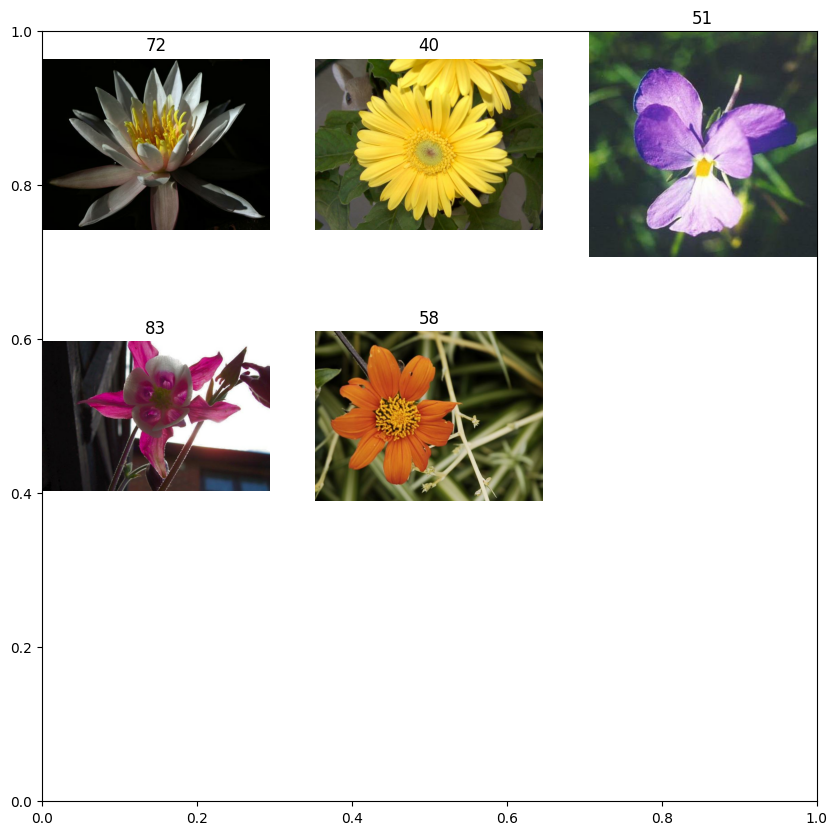

In [4]:
plt.figure(figsize=(10,10))

for image, label in train_dataset.take(9):

    plt.subplot(3,3,len(plt.gca().images)+1)
    plt.imshow(image)
    plt.title(label.numpy())
    plt.axis("off")

plt.show()

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:
def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.one_hot(label, depth=102)

    return image, label

In [7]:
train_dataset = train_dataset.map(preprocess)
validation_dataset = validation_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

In [8]:
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
output = tf.keras.layers.Dense(102, activation='softmax')(x)

model_resnet = tf.keras.Model(inputs=base_model.input, outputs=output)

In [12]:
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history_resnet = model_resnet.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=1
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 405s 13s/step - accuracy: 0.0139 - loss: 4.6618 - val_accuracy: 0.0206 - val_loss: 4.6171


In [16]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
output = tf.keras.layers.Dense(102, activation='softmax')(x)

model_vgg = tf.keras.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=1
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1238s 39s/step - accuracy: 0.0129 - loss: 4.7308 - val_accuracy: 0.0539 - val_loss: 4.5273


In [17]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
output = tf.keras.layers.Dense(102, activation='softmax')(x)

model_mobile = tf.keras.Model(inputs=base_model.input, outputs=output)

model_mobile.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile = model_mobile.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.0615 - loss: 4.5289 - val_accuracy: 0.3461 - val_loss: 3.2361


In [18]:
print("ResNet50 Evaluation")
model_resnet.evaluate(test_dataset)

print("VGG16 Evaluation")
model_vgg.evaluate(test_dataset)

print("MobileNetV2 Evaluation")
model_mobile.evaluate(test_dataset)

ResNet50 Evaluation
193/193 ━━━━━━━━━━━━━━━━━━━━ 1125s 6s/step - accuracy: 0.0202 - loss: 4.6175
VGG16 Evaluation
193/193 ━━━━━━━━━━━━━━━━━━━━ 3690s 19s/step - accuracy: 0.0380 - loss: 4.5379
MobileNetV2 Evaluation
193/193 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.3273 - loss: 3.3533


[3.3318817615509033, 0.3330622911453247]

## Assignment Questions

1. Which model performed best on the Oxford Flowers 102 dataset and why?

2. Compare the performance of the models on Oxford Flowers 102 and CIFAR-100.
What differences do you observe?

3. Discuss the benefits of transfer learning in this assignment.

4. Explain the preprocessing steps you performed and why they were necessary.

5. Describe the architecture of the models and how they were adapted for 102 flower classes.

6. What challenges did you encounter while implementing this assignment?


## Optional Tasks

Students can further improve the model by:

• Trying different learning rates  
• Increasing number of epochs  
• Applying **data augmentation**

Example:

- Random Flip
- Rotation
- Zoom

• Fine-tuning some layers of the pretrained models
• Visualizing predictions on test images

## Conclusion

In this assignment, we applied **transfer learning** using three pre-trained models:

- ResNet50
- VGG16
- MobileNetV2

The models were trained on the **Oxford Flowers 102 dataset** to classify images into 102 flower categories.

Transfer learning allowed us to reuse knowledge from large-scale datasets such as ImageNet, resulting in better performance even with a relatively small dataset.

Finally, we compared the models and analyzed their performance on the test dataset.

## Submission Instructions

1. Complete all code cells.
2. Answer all assignment questions.
3. Run the notebook completely.
4. Save the notebook as:

`Transfer_Learning_Oxford_Flowers.ipynb`

5. Submit the notebook file.